## Stokes Flow in Periodic Channel with Robin boundary.

In [17]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "none"#"last_expr_or_assign"

import numpy as np
import matplotlib.pyplot as plt
from util.logger import EventTracker
from util.basis_scaled import *
from util.plot_tools import *
from boundary_solvers.gauss_grid_2d import StokesDirichletProblem
from scipy.io import loadmat
import matplotlib.pyplot as plt
from util.interp import PiecewiseInterp2D
from boundary_solvers.gauss_grid_2d import TrapezGrid
from hmm.stokes import *
from hmm.stokes_deep import DeepMicroSolver, get_net
import matplotlib
from scipy.interpolate import interp1d
from architecture.session import fno_ver3, fno_ver4, fno_ver1, fno_ver2, egeofno_ver2, svdfno_ver2, svdfno_ver1, svdfno_ver3, egeofno_ver5, svdfno_ver4
import torch

#matplotlib.rcParams['text.usetex'] = False


#net_dir = "/mnt/data0/emastr/article_training_nodecay/"
net_dir = "/mnt/data0/emastr/article_training_hugedata/"
MESH_PATH = "/home/emastr/deep-micro-slip-model/data/mesh/"
figures_dir = "/home/emastr/deep-micro-slip-model/data/figures/"
simulation_dir = "/home/emastr/deep-micro-slip-model/data/stokes_fenics/"
#data_dir = "/home/emastr/deep-micro-slip-model/data/micro_geometries_boundcurv_repar_256_torch/data_big_clean.torch"
run_dir = "/home/emastr/deep-micro-slip-model/data/reference_2/"

#pretty_pyplot_layout()

## Multiscale Problem

We define a multiscale problem as follows. The PDE is a non-slip zero forcing Stokes flow Problem

\begin{equation}
\Delta u  - \nabla p = 0, \qquad \qquad \nabla \cdot u = 0   \qquad \text{inside}\quad \Omega
\end{equation}

with the boundary conditions

\begin{equation}
u = g,\qquad \text{on}\quad\partial\Omega
\end{equation}

the boundary is a two-dimensional pipe with corners at (0,-1) and (1,1), and a micro scale boundary:

In [18]:
i = 41-16#2+16*0#+16#2+16#2+16*3# 2+16#41 # 38 #41 #35 #11 #38 #22 
data, info = StokesData.load_from_matlab(f"{run_dir}run_{i}.mat")
data_0, _ = StokesData.load_from_matlab(f"{run_dir}run_{i}.mat")

data_big_domain = data
dom = data.dom
eval_pos = info["eval_pos"]
eps = info["eps"]
nper = info["nper"]
Lx = info["Lx"]
bbox = info["bbox"]
Uc = info['Uc']
Vc = info['Vc']
Uyc = info['Uyc']

x = np.linspace(bbox[0][0],bbox[0][1],Uc.shape[0])
y = np.linspace(bbox[1][0],bbox[1][1],Uc.shape[1])
X,Y = np.meshgrid(x,y)

pwlerp = PiecewiseInterp2D(x, y, Uc)
from architecture.session import egeofno_ver3, egeofno_ver2, egeofno_ver1, svdfno_ver2, svdfno_ver1, svdfno_ver3, fno_ver2
pwlerp_dy = PiecewiseInterp2D(x, y, Uyc)
pwlerp_alpha = lambda x: -pwlerp(x, np.ones_like(x)*eval_pos) / pwlerp_dy(x, np.ones_like(x)*eval_pos)
print(eps)

0.004641588833612777


### Load Network for evaluation

In [19]:
device = "cpu" # "cuda:0"
num_pts = 256
#net, net_settings = get_net(f"{net_dir}fnoskip_big_data_{40000}.Torch", 256, "cpu", "float")
net_type = 0# 0: egeofno, 1: svdfno, 2: fno_vanilla
# net_type 0 works well

if net_type == 0:
    net = egeofno_ver3(device=device)
    net_data = torch.load(f"{net_dir}fno_ver3_seed0_40000.Torch", map_location=torch.device(device))
elif net_type == 1:
    net = svdfno_ver2(device=device)
    net_data = torch.load(f"{net_dir}svdfno_ver2_seed0_40000.Torch", map_location=torch.device(device))
else:
    net = fno_ver2(device=device)
    net_data = torch.load(f"{net_dir}fno_vanilla_ver2_seed0_40000.Torch", map_location=torch.device(device))

net.load_state_dict(net_data["state dict"])
net_settings =  {"num_pts": num_pts, \
                 "input_features": net_data["settings"]["input_features"], \
                 "output_features": net_data["settings"]["output_features"],\
                 "device": device, "dtype": torch.float}
#print(net_settings["input_features"])
print(net_data["settings"]["output_features"])

['rt', 'rn', 'drt_norm', 'drn_norm']


## Coupling to Micro Domain

To couple the macro domain to the microscopic domain, we make use of the HMM framework.
We construct a set of evenly spaced micro problems based on the Stokes data. The macro problem is constructed with a pre-specified resolution in the x- and y-directions.

StokesData(f=<function StokesData.load_from_matlab.<locals>.<lambda> at 0x7fcef33dbc40>, df=<function StokesData.load_from_matlab.<locals>.<lambda> at 0x7fcef33d9940>, ddf=<function StokesData.load_from_matlab.<locals>.<lambda> at 0x7fcef33da8e0>, g=<function StokesData.load_from_matlab.<locals>.<lambda> at 0x7fcef33d96c0>, dom=[[-1.0, 1.0], [0.001392476650083833, 0.5]], width=2.0, height=0.49860752334991615)


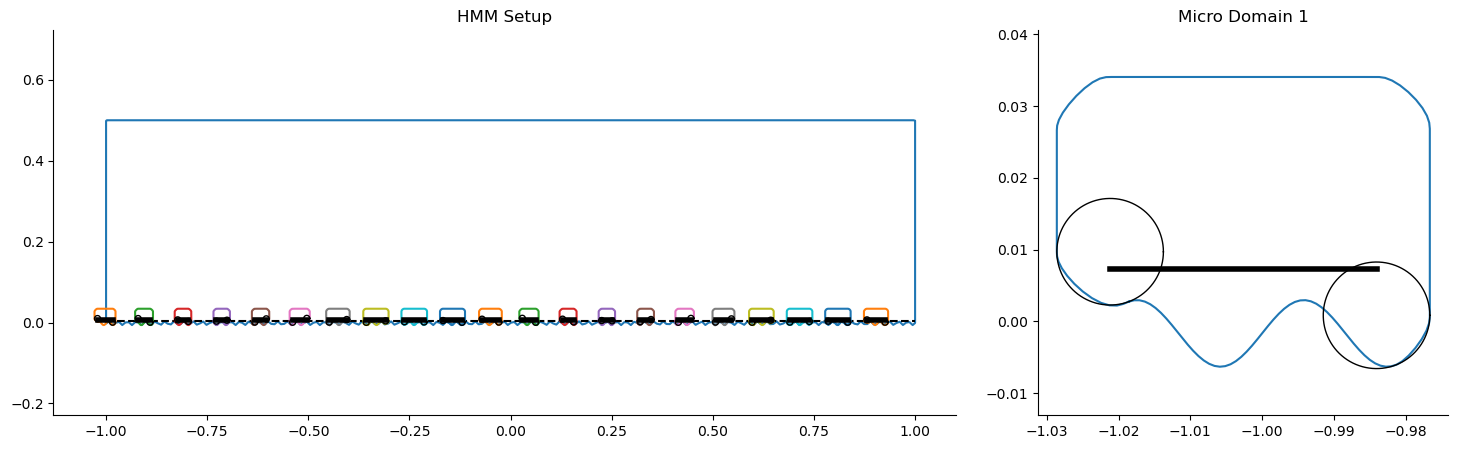

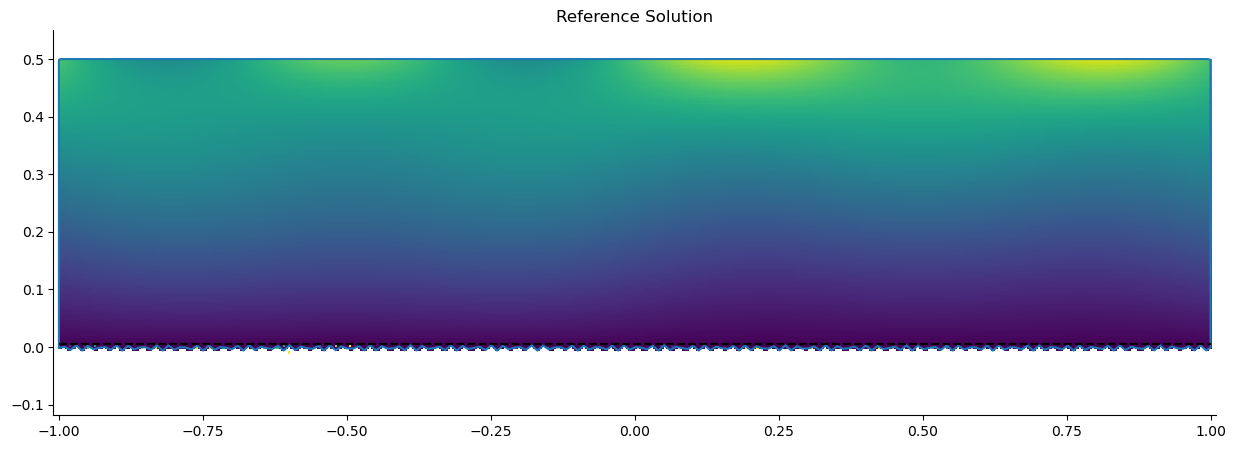

In [20]:

tol = 1e-10
xDim = 21
yDim = 21
nMic = 21#7 #freq_g*2+1#2*(round(Lx/(30*eps)) // 2) + 1 # 15 # 15 #nMic*2 +1
yDim_reduce = 15#51
xDim_reduce = 15#51
width = 5*eps #5*eps #3
height = width*0.8 #3
n_refine = 0
linePos = 0.1

#################
# Macro problem
#################
print(data)
data.dom = [dom[0], [linePos*height+dom[1][0], dom[1][1]]] # Make sure line is bottom of domain

# Mean
#macro = StokesMacProb(data, lambda x, a: lambda y: np.mean(a)*np.ones_like(y))
#macro_0 = StokesMacProb(data_0, lambda x,a: lambda y: np.mean(a)*np.ones_like(y))
      
# FFT                  
macro = StokesMacProb(data, lambda x, a: fft_interp(x, a, dom=dom[0]))
macro_0 = StokesMacProb(data_0, lambda x, a: fft_interp(x, a, dom=dom[0])) # For comparison
###################
# Micro problems
###################


#data.dom = [dom[0], [linePos*height, dom[1][1]]]
#xPos = np.linspace(dom[0][0]+4*eps, dom[0][1]-4*eps, nMic)-2*eps
xPos = np.linspace(dom[0][0], dom[0][1], nMic+1)[1:] - width/2 - Lx / nMic
#micros = [StokesMicProb(data, x, width, height, linePos=linePos, deg_project=8, 
#                        n_refine=n_refine, xDim_reduce=xDim_reduce, yDim_reduce=yDim_reduce) for x in xPos]
micros = [StokesTrapezMicProb(data, x, width, height, linePos=linePos, deg_project=8, logger=None, 
                              num_pts=64, xDim_reduce=xDim_reduce, yDim_reduce=yDim_reduce) for x in xPos]

###################
# Hmm problem.
conv_checker = ConvergenceChecker(macro, micros, tol=tol)
hmm_prob = StokesHMMProblem(macro, micros, data, convergence_checker=conv_checker)

###################
## PLOT ##
plt.figure(figsize=(18,5))


plt.subplot2grid((1, 3), (0, 0), 1, 2)
plt.title("HMM Setup")
hmm_prob.plot(plt.gca())
plt.axis("Equal")
remove_top_right_axes(plt.gca())

plt.subplot2grid((1, 3), (0, 2), 1, 1)
plt.title("Micro Domain 1")
micros[0].plot(plt.gca())
plt.axis("equal")
remove_top_right_axes(plt.gca())

# Plot

vmin, vmax= 0, .7
plt.figure(figsize=(15,5))
plt.title("Reference Solution")
plt.pcolormesh(X, Y, Uc, vmin=vmin, vmax=vmax)
data.plot(plt.gca(), npts=800)
plt.axis("equal")
remove_top_right_axes(plt.gca())
plt.ylim([dom[1][0]-0.12, dom[1][1]+0.05])



## Solving using HMM iterations

To solve the problem, we make use of a sequence of micro solvers, as well as a micro solver.

In [21]:
micro_logger = EventTracker() # Log time
micro_logger_deep = EventTracker() # Log time
macro_logger = EventTracker()
naive_logger = EventTracker()

macro_solver = MacroSolver(xDim, yDim, tol=tol, logger=macro_logger)
macro_solver_0 = MacroSolver(xDim, yDim, tol=tol, logger=naive_logger)

print("Deep precomputing...")
micro_logger_deep.start_event("micro precompute")
deep_micro_solvers = [DeepMicroSolver(m, net, net_settings, tol=tol, logger=micro_logger_deep) for m in micros]
micro_logger_deep.end_event("micro precompute")

class CountCallback():
    def __init__(self):
        self.count = 0
    def __call__(self, *args):
        self.count += 1
counters = [CountCallback() for m in micros]
    
print("Classic precomputing...")
micro_logger.start_event("micro precompute")
micro_solvers = [MicroSolver(m, logger=micro_logger, tol=tol, callback=c) for m, c in zip(micros, counters)]
micro_logger.end_event("micro precompute")
print("Done")


deep_hmm_solver = IterativeHMMSolver(macro_solver, deep_micro_solvers)
hmm_solver = IterativeHMMSolver(macro_solver, micro_solvers)

class Callback():
    def __init__(self, macro):
        self.N = 100
        self.x = np.linspace(0,1,self.N)
        self.macro = macro
        self.current_alpha = macro.alpha(self.x)
        self.diff = []
        self.micro_errors = []
    
    def __call__(self, it, macro_sol, micro_sols):
        errors = []
        for deep_micro, micro, prob in zip(deep_micro_solvers, micro_solvers, micros):
            deep_sol = deep_micro.solve(prob)
            sol = micro.solve(prob)
            errors.append(np.abs((deep_sol.alpha - sol.alpha) / sol.alpha))
            #r_true, _ = micro.geom.precompute_line_avg(derivative=0)
            #t1, _ = micro.geom.grid.get_grid_and_weights()
            #r_true_t = interp1d(t1, r_true, kind="cubic")(micro.t)
            #errors.append(np.linalg.norm(micro.r - r_true_t)/np.linalg.norm(r_true_t))
        self.micro_errors.append(errors)
        self.previous_alpha = self.current_alpha
        self.current_alpha = self.macro.alpha(self.x)
        self.diff.append(np.linalg.norm(self.previous_alpha - self.current_alpha) / self.N**0.5)
       
debug_cb = Callback(macro)

print([c.count for c in counters])

Deep precomputing...
Classic precomputing...
Done
[30, 25, 23, 23, 24, 29, 33, 35, 33, 35, 32, 29, 24, 22, 23, 28, 31, 34, 35, 35, 32]


error in r: 2.85e-01, in dr: 2.61e-01
error in r: 3.56e-01, in dr: 2.76e-01
error in r: 2.47e-01, in dr: 2.59e-01
error in r: 2.29e-01, in dr: 1.40e-01
error in r: 2.08e-01, in dr: 1.35e-01
error in r: 2.36e-01, in dr: 1.69e-01
error in r: 2.11e-01, in dr: 1.44e-01
error in r: 2.15e-01, in dr: 2.00e-01
error in r: 2.28e-01, in dr: 1.95e-01
error in r: 1.97e-01, in dr: 2.11e-01
error in r: 1.94e-01, in dr: 2.16e-01
error in r: 3.59e-01, in dr: 3.05e-01
error in r: 3.19e-01, in dr: 2.48e-01
error in r: 2.28e-01, in dr: 1.55e-01
error in r: 2.16e-01, in dr: 1.28e-01
error in r: 2.13e-01, in dr: 1.69e-01
error in r: 2.37e-01, in dr: 1.49e-01
error in r: 2.35e-01, in dr: 2.06e-01
error in r: 2.17e-01, in dr: 1.87e-01
error in r: 2.12e-01, in dr: 2.13e-01
error in r: 1.94e-01, in dr: 2.13e-01


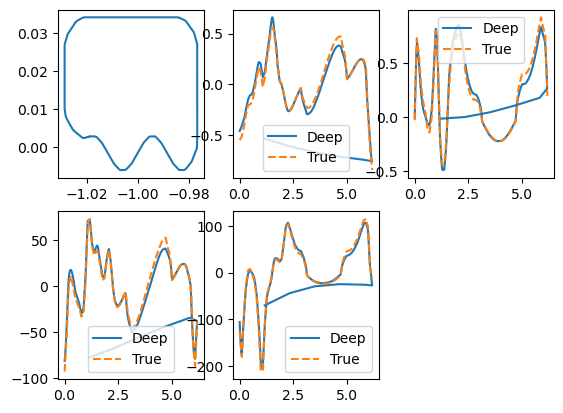

In [22]:
def interp_periodic(t, y, tval):
    t = np.concatenate([[t[-1]-np.pi*2], t, [t[0] + np.pi*2]])
    y = np.concatenate([[y[-1]], y, [y[0]]])
    return interp1d(t, y, kind="cubic")(tval)

num_mic = len(micro_solvers)
sqrt_num_mic = int(np.ceil(num_mic**0.5))
for i, (s, self) in enumerate(zip(micro_solvers, deep_micro_solvers)):
    #print(list(ds.__dict__.keys()))
    self.r_true, self.avg_true = self.geom.precompute_line_avg(derivative=0)
    self.dr_true, self.davg_true = self.geom.precompute_line_avg(derivative=1)
    t1, _ = self.geom.grid.get_grid_and_weights()
    r_true_t = interp_periodic(t1, self.r_true, self.t)
    dr_true_t = interp_periodic(t1, self.dr_true, self.t)
    
    #plt.plot(self.t, r_true_t)
    #plt.plot(self.t, self.r)
    
    
    #plt.figure(1, figsize=(7,15))
    
    #plt.subplot(2*sqrt_num_mic, sqrt_num_mic, i+1)
    #plt.plot(self.t, np.abs(r_true_t))
    #plt.plot(self.t, np.abs(self.r), '--')
    #plt.plot(self.t, np.abs(self.r - r_true_t), ':')
    
    #plt.subplot(2*sqrt_num_mic, sqrt_num_mic, sqrt_num_mic**2 + i + 1)
    #plt.plot(self.t, np.abs(dr_true_t))
    #plt.plot(self.t, np.abs(self.dr), '--')
    #plt.plot(self.t, np.abs(self.dr - dr_true_t), ':')
    print(f"error in r: {np.linalg.norm(self.r - r_true_t)/np.linalg.norm(r_true_t):.2e}, " +\
           f"in dr: {np.linalg.norm(self.dr - dr_true_t)/np.linalg.norm(dr_true_t):.2e}")
#plt.plot(ds.dr[::2].imag)
#lt.plot(ds.dr_true.imag)
#deep_micro_solvers[0].plot()  

for i in range(1):#len(micro_solvers)):
    plt.figure()
    deep_micro_solvers[i].plot()

In [23]:
macro_guess = macro_solver_0.solve(macro_0)

print("Deep HMM Solver...")
for i in range(4):
    micro_logger_deep.start_event("hmm solve")
    (deep_macro_sol, deep_micro_sols) = deep_hmm_solver.solve(hmm_prob, macro_guess=macro_guess, 
                                            callback=debug_cb, verbose=True, maxiter=3, tol=tol, logger=None)
    micro_logger_deep.end_event("hmm solve")
print("\nDone")

deep_diff = debug_cb.diff
debug_cb.diff = []
debug_cb.micro_errors = []

print("Classic HMM Solver...")
for i in range(4):
    micro_logger.start_event("hmm solve")
    (macro_sol, micro_sols) = hmm_solver.solve(hmm_prob, macro_guess=macro_guess, 
                                            callback=debug_cb, verbose=True, maxiter=3, tol=tol, logger=None)
    micro_logger.end_event("hmm solve")
print("\nDone")





Deep HMM Solver...
Step 2/3
Done
Classic HMM Solver...
Step 2/3
Done


### Convergence and computation time

$4.684\pm0.077$ & $0.024\pm0.009$ \\
$5.362\pm0.315$ & $0.009\pm0.001$ \\
0.008547408240182061
0.5010662078857422


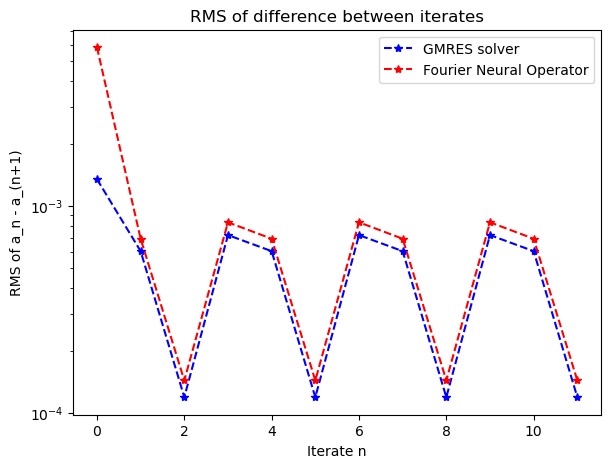

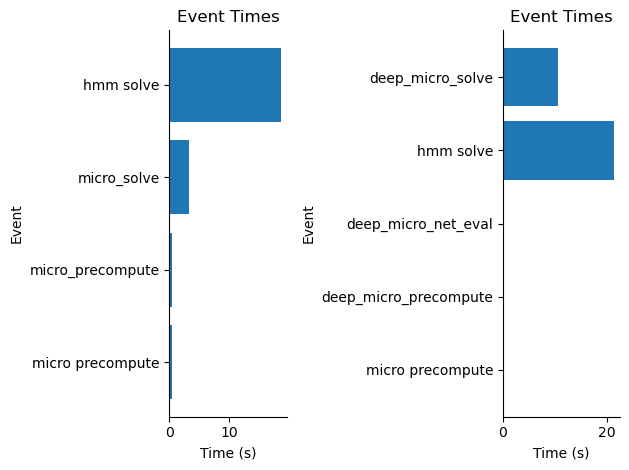

In [24]:
plt.figure(figsize=(15,5))
plt.subplot(122)
plt.title("RMS of difference between iterates")
plt.semilogy(debug_cb.diff, 'b*--', label='GMRES solver')
plt.semilogy(deep_diff, 'r*--', label='Fourier Neural Operator')

plt.legend()
plt.xlabel("Iterate n")
plt.ylabel("RMS of a_n - a_(n+1)")

#plt.subplot(121)
plt.figure()
def print_table(rows, errs, print_stds):
    for row, err, print_std in zip(rows, errs, print_stds):
        mean_pm_err = [f"${r:.3f}\\pm{e:.3f}$" if prs else f"${r:.1f}$" for r, e, prs in zip(row, err, print_std)]
        print(" & ".join(mean_pm_err) + " \\\\")

rows = [[data_dict.events[label].time_mean for label in data_labels] for data_dict, data_labels in [(micro_logger, ["hmm solve", "micro_precompute"]), (micro_logger_deep, ["hmm solve", "deep_micro_net_eval"])]]
errs = [[data_dict.events[label].time_std*2 for label in data_labels] for data_dict, data_labels in [(micro_logger, ["hmm solve", "micro_precompute"]), (micro_logger_deep, ["hmm solve", "deep_micro_net_eval"])]]
print_stds = [[True, True], [True, True]]
print_table(rows, errs, print_stds)
print(micro_logger_deep.events["deep_micro_net_eval"].time_mean)
print(micro_logger.events["micro precompute"].time_mean)
plt.subplot(121)
micro_logger.barplot_logs(plt.gca())

plt.subplot(122)
micro_logger_deep.barplot_logs(plt.gca())
plt.tight_layout()


## Accuracy
We use the reference solver data to construct a piecewise linear interpolation. Also, the micro data is used to construct a set of full solutions to the velocity field in the micro problems for visualisation purposes.

Verifying derivatives